# Машинное обучение, ФКН ВШЭ

## Практическое задание 6. Разложение ошибки на смещение и разброс

### Общая информация

Дата выдачи: 20.11.2020

Мягкий дедлайн: 00:59MSK 02.12.2019

Жесткий дедлайн: 00:59MSK 07.12.2019

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-06-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

### О задании

В этом задании вам предстоит воспользоваться возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения. Делать мы это будем на данных boston:

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [3]:
X = data
y = target

In [4]:
X.shape, y.shape

((506, 13), (506,))

### Вычисление bias и variance с помощью бутстрапа
На лекции была выведено следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) = 
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] = 
$$
$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### Приближенное вычисление интегралов
На занятиях мы разбирали примеры аналитического вычисления смещения и разброса нескольких алгоритмов обучения. Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [5]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(34.206996726003595)

#### Оценивание $\mathbb{E}_{x, y}$
Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка. 

#### Оценивание $\mathbb{E}_X$ с помощью бутстрапа
Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

#### Итоговый алгоритм оценки смещения и разброса алгоритма $a$
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$. 

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$. 

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__1. (3 балла)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

def compute_biase_variance(regressor, X, y, num_runs=1000):
    """
    :param regressor: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set of objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)
    
    :returns: bias (float), variance (float), error (float) 
    each value is computed using bootstrap
    """
    X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

    # get X from bootstrap
    n_samples = X.shape[0]
    predictions = np.full((n_samples, num_runs), np.nan)

    for run in range (num_runs):
        all_indices = [i for i in range(n_samples)]
        fit_choise = np.random.randint(0, n_samples, size=n_samples)
        out_of_bag = list(set(all_indices) - set(fit_choise))
        mask = X.index.isin(out_of_bag)
        
        regressor.fit(X.iloc[fit_choise], y[fit_choise])
        # Каждый столбец predictions - новая модель на новой выборке, есть NaN
        if mask.any():
            predictions[mask, run] = regressor.predict(X[mask])
    
    y_mean = np.nanmean(predictions, axis=1).reshape(-1, 1)
    bias = np.nanmean(np.nanmean((y_mean - y.reshape(-1, 1))**2, axis=1), axis=0)
    variance = np.nanmean(np.nanvar(predictions, axis=1), axis=0)
    error = np.nanmean(np.nanmean((predictions - y.reshape(-1, 1))**2, axis=1), axis=0)
    # print(f'bias = {bias:.1f}')
    # print(f'var = {variance:.1f}')
    # print(f'err = {error:.1f}')
    return bias, variance, error


# compute_biase_variance(LinearRegression(), X, y, num_runs=1000)
biasses = []
variances = []
errors = []
depths = [1, 2, 5, 10, 12, 15, 17, 19, 20]
for m_d in depths:
    # bias, variance, error = compute_biase_variance(
    #     DecisionTreeRegressor(
    #         splitter='best',
    #         max_depth=m_d,
    #         min_samples_leaf=1,
    #         random_state=42
    #         ), 
    #     X, 
    #     y, 
    #     num_runs=1000
    # )
    # bias, variance, error = compute_biase_variance(RandomForestRegressor(n_estimators=100, max_depth=m_d, random_state=42), X, y, num_runs=100)
    bias, variance, error = compute_biase_variance(LinearRegression(), X, y, num_runs=1000)
    biasses.append(bias)
    variances.append(variance)
    errors.append(error)
    

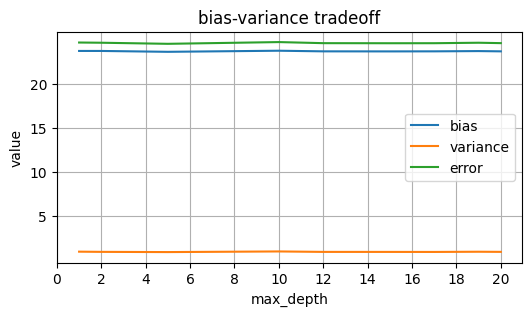

bias: 23.7
variance: 0.9
error: 24.6


In [7]:
plt.figure(figsize=(6, 3))
plt.plot(depths, biasses, label='bias')
plt.plot(depths, variances, label='variance')
plt.plot(depths, errors, label='error')
plt.xlabel('max_depth')
plt.ylabel('value')
plt.yticks([i for i in range(5, int(max(errors)), 5)])
plt.xticks([i for i in range(0, 21, 2)])
plt.title('bias-variance tradeoff')
plt.grid()
plt.legend()
plt.show()
print(f'bias: {min(biasses):.1f}\nvariance: {min(variances):.1f}\nerror: {min(errors):.1f}')

__2. (0 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

In [8]:
### your code here

__3. (1 балл)__
Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что мы обсуждали на занятиях (с комментарием)?

__Your answer here:__

__4. (1 балл)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

__Your answer here:__

### Визуализация предсказаний базовых алгоритмов бэггинга

В материалах лекций можно найти изображение, похожее на мишень - визуализация алгоритмов с разным смещением и разным разбросом. В центре "мишени" - правильный ответ, а "попадания" - предсказания алгоритмов, обученных по разным выборкам. Построим похожее изображение на наших данных для трех алгоритмов. Наши "мишени" будут одномерными, потому что мы решаем задачу одномерной регрессии.

__5. (2 балла)__

Реализуйте фукнцию plot_predictions. Она должна выполнять следующие действия:
1. Случайно выбрать num_test_objects пар объект-целевая переменная из выборки X, y. Получится две выборки: маленькая X_test, y_test (выбранные тестовые объекты) и X_train, y_train (остальные объекты).
1. Сгенерировать num_runs выборок методом бутстарапа из X_train, y_train. На каждой выборке обучить алгоритм regressor и сделать предсказания для X_test.
1. Нарисовать scatter-график. По оси абсцисс - объекты тестовой выборки (номера от 0 до num_test_objects-1), по оси ординат - предсказания. В итоге получится num_test_objects столбиков с точками. Для каждого тестового объекта надо отметить одним цветом все предсказания для него, а также черным цветом отметить правильный ответ.
1. Подпишите оси и название графика (аргумент title).

KeyboardInterrupt: 

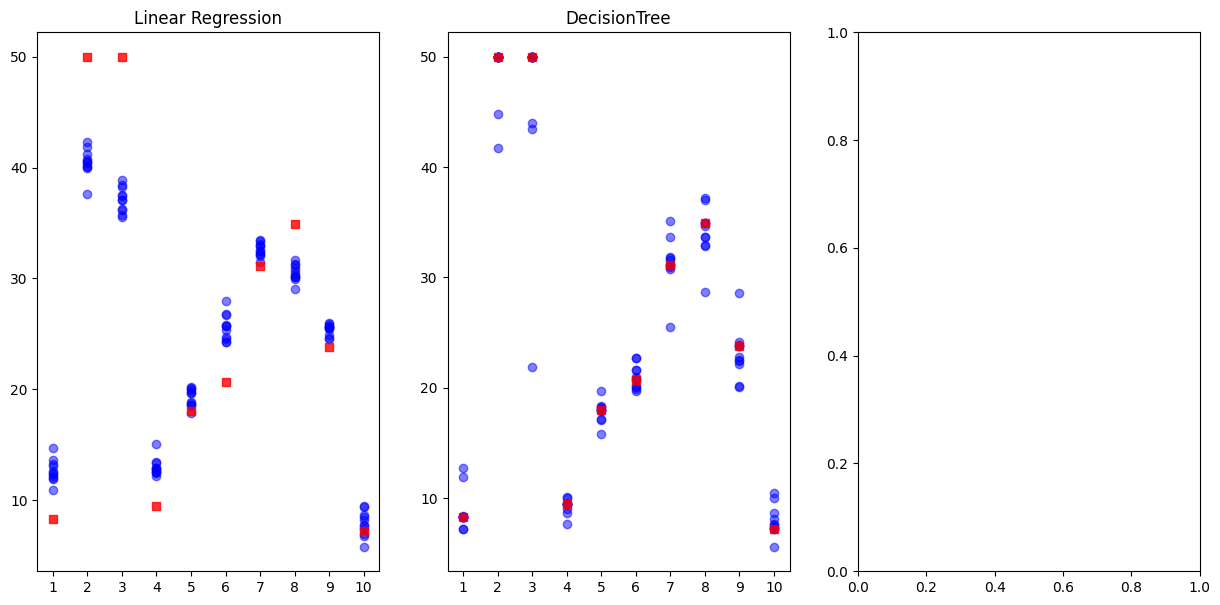

In [9]:
def plot_predictions(test_indices, regressor, X, y, num_runs=100, num_test_objects=10, title="", ax=None):
    # 1) get X from bootstrap
    X = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

    # get X from bootstrap
    n_samples = X.shape[0]
    predictions = np.full((num_test_objects, num_runs), np.nan)

    X_test = X.iloc[test_indices]
    y_test = y[test_indices]

    for run in range (num_runs):
        all_indices = [i for i in range(n_samples)] 
        fit_choise = np.random.randint(0, n_samples, size=n_samples)
        out_of_bag = list(set(all_indices) - set(fit_choise) - set(test_indices))
        
        regressor.fit(X.iloc[fit_choise], y[fit_choise])
        # Каждый столбец predictions - новая модель на новой выборке, есть NaN
        predictions[:, run] = regressor.predict(X_test)
    
    # y_mean = np.nanmean(predictions, axis=1).reshape(-1, 1)
    # bias = np.nanmean(np.nanmean((y_mean - y.reshape(-1, 1))**2, axis=1), axis=0)
    # variance = np.nanmean(np.nanvar(predictions, axis=1), axis=0)
    # error = np.nanmean(np.nanmean((predictions - y.reshape(-1, 1))**2, axis=1), axis=0)
    # print(f'bias = {bias:.1f}')
    # print(f'var = {variance:.1f}')
    # print(f'err = {error:.1f}')
    pr_df = pd.DataFrame(predictions, columns=[f'model_{i}' for i in range(num_runs)])
    # print(pr_df)
    # print(f'predictions shape: {predictions.shape}')
    for i in range(num_test_objects+1):
        ax.plot([range(1, num_test_objects+1)], predictions[:, i].reshape(1, -1), marker='o', color='blue', linestyle='', alpha=0.5)
    ax.plot([range(1, num_test_objects+1)], y_test.reshape(1, -1), marker='s', linestyle='', alpha=0.8, color='red', label='true value')
    ax.set_xticks([i for i in range(1, num_test_objects+1)])
    ax.set_title(title)
    # return bias, variance, error

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
n_runs = 1000
test_size = 10
test_indices = np.random.randint(1, X.shape[0], size=test_size)
plot_predictions(test_indices, LinearRegression(), X, y, num_runs=n_runs, num_test_objects=test_size, title="Linear Regression", ax=axes[0])
plot_predictions(test_indices, DecisionTreeRegressor(max_depth=10), X, y, num_runs=n_runs, num_test_objects=test_size, title="DecisionTree", ax=axes[1])
plot_predictions(test_indices, RandomForestRegressor(n_estimators=200, random_state=42), X, y, num_runs=n_runs, num_test_objects=test_size, title="RandomForest", ax=axes[2])

y_min = min(ax.get_ylim()[0] for ax in axes)
y_max = max(ax.get_ylim()[1] for ax in axes)
for ax in axes:
    ax.set_ylim(y_min, y_max)
plt.show()




Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса. Нарисуйте три графика в строчку (это можно сделать с помощью plt.subplot) с одинаковой осью ординат (это важно для понимания масштаба разброса у разных алгоритмов):

__7. (1 балл)__

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма. 

__Your answer here:__

### Изменение bias и variance при изменении гиперпараметров

__8. (0 баллов)__


Постройте графики зависимости смещения и разброса от гиперпараметров решающего дерева max_depth (от 1 до 10) и max_features (от 1 до X.shape[1]):

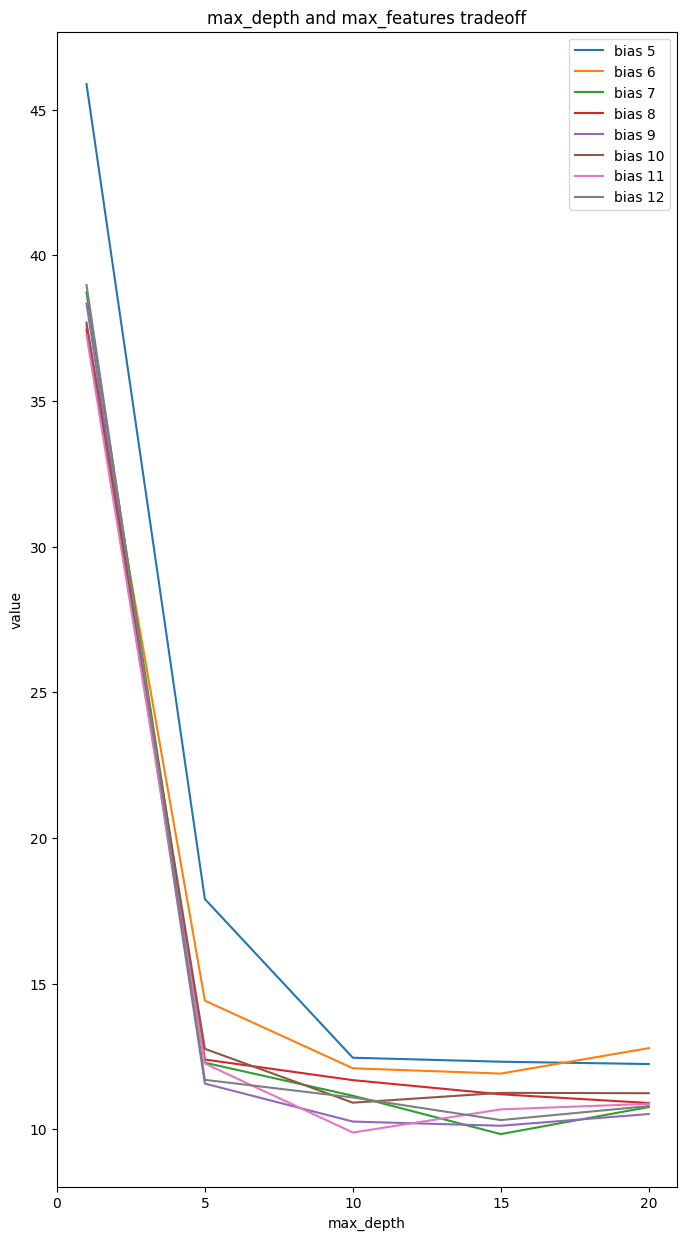

In [10]:
biasses = []
variances = []
errors = []
depths = [1, 5, 10, 15, 20]
num_features = [i for i in range(5, X.shape[1])]

plt.figure(figsize=(8, 15))

for m_f in num_features:
    biasses = []
    variances = []
    errors = []
    for m_d in depths:
        bias, variance, error = compute_biase_variance(
            DecisionTreeRegressor(
                splitter='best',
                max_depth=m_d,
                max_features=m_f,
                min_samples_leaf=1,
                random_state=42
                ), 
            X, 
            y, 
            num_runs=100
        )
        biasses.append(bias)
        variances.append(variance)
        errors.append(error)
    
    plt.plot(depths, biasses, label=f'bias {m_f}')
    # plt.plot(depths, variances, label=f'variance {m_f}')
    # plt.plot(depths, errors, label='error')
    plt.xlabel('max_depth')
    plt.ylabel('value')
    # plt.yticks([i for i in range(5, int(max(errors)), 5)])
    plt.xticks([i for i in range(0, 21, 5)])
    plt.title('max_depth and max_features tradeoff')
    plt.grid()
    plt.legend()

plt.show()
    # print(f'bias: {min(biasses):.1f}\nvariance: {min(variances):.1f}\nerror: {min(errors):.1f}')


__9. (0 баллов)__

Постройте графики зависимости смещения и разброса от n_estimators (по сетке 2**np.arange(1, 10)) для случайного леса и градиентного бустинга:

In [11]:
np.arange(1,10)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [12]:
num_est = [2 ** i for i in np.arange(1,10)]

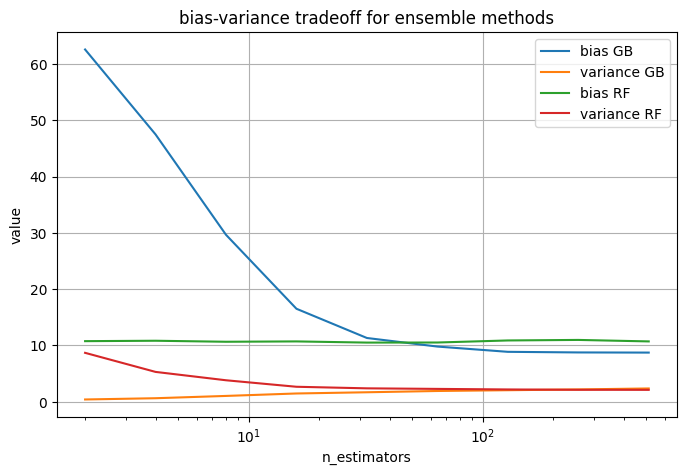

In [15]:
from sklearn.ensemble import GradientBoostingRegressor

b_gb = []
v_gb = [] 
b_rf = []
v_rf = []

for n_e in num_est:
    bias, variance, _ = compute_biase_variance(
        GradientBoostingRegressor(n_estimators=n_e, random_state=42), 
        X, 
        y, 
        num_runs=100
    )

    b_gb.append(bias)
    v_gb.append(variance)
    
    bias, variance, _ = compute_biase_variance(
        RandomForestRegressor(n_estimators=n_e, random_state=42), 
        X, 
        y, 
        num_runs=100
    )
    b_rf.append(bias)
    v_rf.append(variance)

plt.figure(figsize=(8, 5))
plt.plot(num_est, b_gb, label='bias GB')
plt.plot(num_est, v_gb, label='variance GB')
plt.plot(num_est, b_rf, label='bias RF')
plt.plot(num_est, v_rf, label='variance RF')
plt.xlabel('n_estimators')
plt.ylabel('value')
plt.xscale('log')
plt.title('bias-variance tradeoff for ensemble methods')
plt.grid()
plt.legend()
plt.show()

__10. (2 балла)__

Прокомментируйте графики (всего 4 графика): почему они имеют такой вид.

__Your answer here:__